<a href="https://colab.research.google.com/github/bigirimanainnocent12/Spark/blob/main/PYSPARK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Description de la base de données***

Cet ensemble de données recense les incidents criminels signalés (à l'exception des homicides pour lesquels des données existent pour chaque victime) survenus dans la ville de Chicago de 2001 à 14/11/2025, moins les sept derniers jours. Les données proviennent du système CLEAR (Citizen Law Enforcement Analysis and Reporting) du département de police de Chicago. Afin de protéger la vie privée des victimes, les adresses sont affichées au niveau du pâté de maisons uniquement et les lieux précis ne sont pas identifiés. Pour toute question concernant cet ensemble de données, veuillez contacter la Division de l'analyse et du traitement des données du département de police de Chicago à l'adresse DFA@ChicagoPolice.org.

[
Lien pour télécharger les données](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data)

In [106]:
!pip install pyspark
!pip install findspark

In [107]:
from pyspark.sql import SparkSession
spark=SparkSession.builder.appName("Analyse des crimes dans la ville de Chicago").getOrCreate()

# **Importation des données et affichage de 20 premières lignes**

In [108]:
df=spark.read.csv("/content/drive/MyDrive/BOURSE DATA SCIENCE/crimes.csv",header=True,inferSchema=True)
df.show()

+--------+-----------+--------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|      ID|Case Number|                Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|          Updated On|    Latitude|    Longitude|            Location|
+--------+-----------+--------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|14047576|   JJ512272|12/05/2025 12:00:...|   053XX N LYNCH AVE|1310|     CRIMINAL DAMAGE|         TO PROPERTY|           RE

# ***chargement des types des variables***

In [109]:
from pyspark.sql.functions import col, to_timestamp

df = df.withColumn("Date", to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a")) \
       .withColumn("Latitude", col("Latitude").cast("float")) \
       .withColumn("Longitude", col("Longitude").cast("float")) \
       .withColumn("Updated On", to_timestamp(col("Updated On"), "MM/dd/yyyy hh:mm:ss a"))
df.show()

+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+
|      ID|Case Number|               Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|         Updated On| Latitude| Longitude|            Location|
+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+
|14047576|   JJ512272|2025-12-05 00:00:00|   053XX N LYNCH AVE|1310|     CRIMINAL DAMAGE|         TO PROPERTY|           RESIDENCE|  true|    true|1

In [110]:
df.dtypes

[('ID', 'int'),
 ('Case Number', 'string'),
 ('Date', 'timestamp'),
 ('Block', 'string'),
 ('IUCR', 'string'),
 ('Primary Type', 'string'),
 ('Description', 'string'),
 ('Location Description', 'string'),
 ('Arrest', 'boolean'),
 ('Domestic', 'boolean'),
 ('Beat', 'int'),
 ('District', 'int'),
 ('Ward', 'int'),
 ('Community Area', 'int'),
 ('FBI Code', 'string'),
 ('X Coordinate', 'int'),
 ('Y Coordinate', 'int'),
 ('Year', 'int'),
 ('Updated On', 'timestamp'),
 ('Latitude', 'float'),
 ('Longitude', 'float'),
 ('Location', 'string')]

# ***Nombre de valeurs nulles par colonne***

In [111]:
from pyspark.sql.functions import col,sum
df.select([sum(col(c).isNull().cast('int').alias(c)) for c in df.columns]).show()

+------------------------------------+--------------------------------------------------------+----------------------------------------+------------------------------------------+----------------------------------------+----------------------------------------------------------+------------------------------------------------------+--------------------------------------------------------------------------+--------------------------------------------+------------------------------------------------+----------------------------------------+------------------------------------------------+----------------------------------------+--------------------------------------------------------------+--------------------------------------------------+----------------------------------------------------------+----------------------------------------------------------+----------------------------------------+------------------------------------------------------+--------------------------------------

# ***CRIMINAL SEXUAL ASSAULT==CRIM SEXUAL ASSAULT***

In [112]:
from pyspark.sql.functions import when, col
df = df.withColumn(
    "Primary Type",
    when(col("Primary Type") =="CRIM SEXUAL ASSAULT","CRIMINAL SEXUAL ASSAULT")
    .otherwise(col("Primary Type"))
)
df.show()

+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+
|      ID|Case Number|               Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|         Updated On| Latitude| Longitude|            Location|
+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+
|14047576|   JJ512272|2025-12-05 00:00:00|   053XX N LYNCH AVE|1310|     CRIMINAL DAMAGE|         TO PROPERTY|           RESIDENCE|  true|    true|1

# ***Création des quelques colonnes importantes***

In [113]:
from pyspark.sql.functions import col,dayofmonth,month,weekday,when
df = df.withColumn("Jour du mois", dayofmonth(col("Date")))\
       .withColumn("mois de l'incident",month(col("Date")))\
       .withColumn("Jour de la semaine",weekday(col("Date")))\
       .withColumn("Week_end",when(col("Jour de la semaine").isin(0,4),0).otherwise(1))
df.show()

+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+------------+------------------+------------------+--------+
|      ID|Case Number|               Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|         Updated On| Latitude| Longitude|            Location|Jour du mois|mois de l'incident|Jour de la semaine|Week_end|
+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+------------+----------------

In [114]:
def mois(mois):
  if mois==1:
    return "Janvier"
  elif mois==2:
    return "Février"
  elif mois==3:
    return 'Mars'
  elif mois==4:
    return 'Avril'
  elif mois==5:
    return 'Mai'
  elif mois==6:
    return 'Juin'
  if mois==7:
    return "Juillet"
  elif mois==8:
    return "Août"
  elif mois==9:
    return 'Septembre'
  elif mois==10:
    return 'Octobre'
  elif mois==11:
    return 'Novembre'
  else:
    return 'Décembre'

def jourdelasemaine(jour):
  if jour==0:
    return "Lundi"
  if jour==1:
    return "Mardi"
  if jour==2:
    return "Mecredi"
  if jour==3:
    return "Jeudi"
  if jour==4:
    return "Vendredi"
  if jour==5:
    return "Samedi"
  if jour==6:
    return "Dimanche"

In [115]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
mois_udf=udf(mois,StringType())
jourdelasemaine_udf=udf(jourdelasemaine,StringType())
df=df.withColumn("mois de l'incident",mois_udf(col("mois de l'incident")))
df=df.withColumn("Jour de la semaine",jourdelasemaine_udf(col("Jour de la semaine")))
df.show()

+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+------------+------------------+------------------+--------+
|      ID|Case Number|               Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|         Updated On| Latitude| Longitude|            Location|Jour du mois|mois de l'incident|Jour de la semaine|Week_end|
+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+------------+----------------

# ***Taux d'arrestation***

In [149]:
print(f"Le taux d'arrestation à chicago est de {(df.filter(col('Arrest')=="true").count()/df.count())*100}%")

Le taux d'arrestation à chicago est de 25.189348712305808%


In [ ]:
from numpy._core.multiarray import inner
arrestation_an=df.filter(col('Arrest')==True).groupBy("Year").count()
nombre_incident_an=df.groupBy('Year').count()
arrestation_an.join(nombre_incident_an,on="Year",how="inner")
arrestation_an.show()

# ***Le nombre d'incident par an***

In [116]:
df.groupBy('Year').count().show()

+----+------+
|Year| count|
+----+------+
|2025|219935|
|2024|258852|
|2023|263201|
|2022|239956|
|2019|261679|
|2020|212674|
|2021|209621|
|2018|269128|
|2016|269946|
|2017|269276|
|2015|264880|
|2014|275874|
|2013|307607|
|2012|336369|
|2011|352047|
|2010|370562|
|2009|392863|
|2008|427214|
|2007|437106|
|2006|448197|
+----+------+
only showing top 20 rows


# ***Nombre d'incident de 2006 à 2025***

Text(0.5, 0, 'Année')

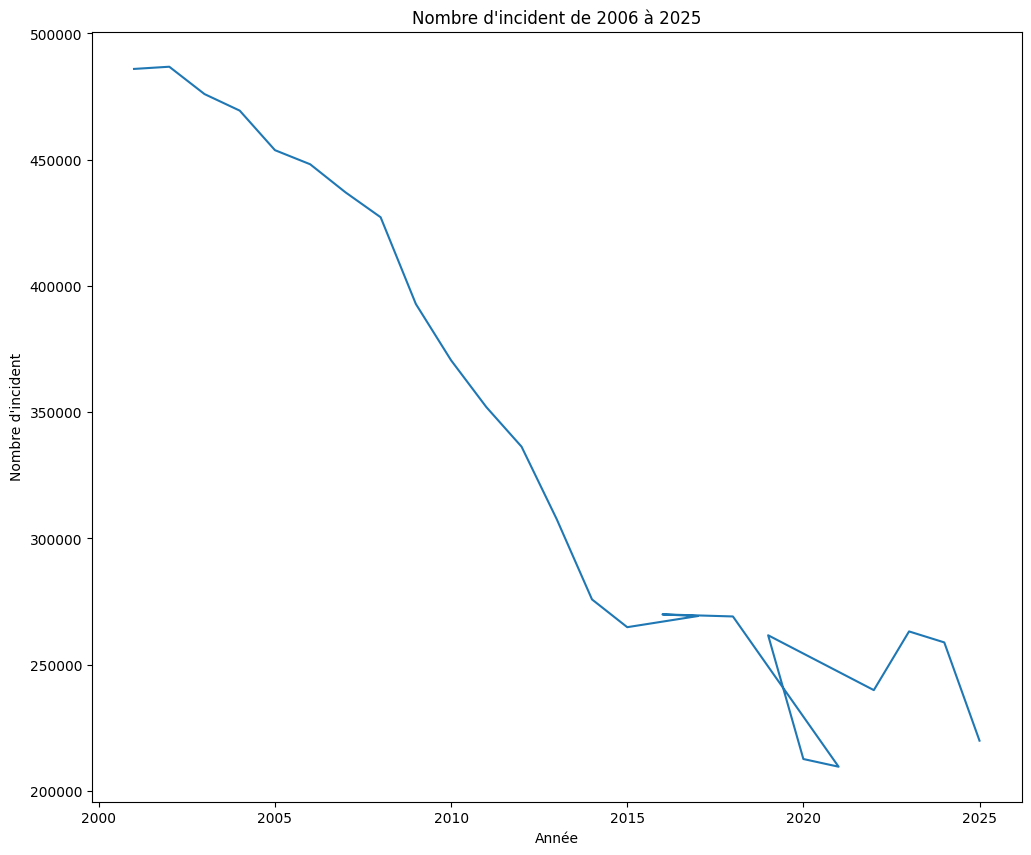

In [117]:
import matplotlib.pyplot as plt
nombre_incident_an=(df.groupBy('Year').count()).toPandas()
plt.figure(figsize=(12, 10))
plt.plot(nombre_incident_an.Year,nombre_incident_an['count'])
plt.title("Nombre d'incident de 2006 à 2025")
plt.ylabel("Nombre d'incident")
plt.xlabel("Année")

# ***Nombre d'incident par mois***

In [118]:
df.groupBy("mois de l'incident").count().show()

+------------------+------+
|mois de l'incident| count|
+------------------+------+
|          Décembre|622885|
|             Avril|688330|
|              Mars|691398|
|           Juillet|788167|
|         Septembre|734303|
|           Octobre|742819|
|           Janvier|661356|
|              Août|779142|
|               Mai|748874|
|           Février|584479|
|          Novembre|668223|
|              Juin|749020|
+------------------+------+



In [119]:
df.groupBy(["mois de l'incident","Arrest"]).count().orderBy("mois de l'incident",ascending=False).show()

+------------------+------+------+
|mois de l'incident|Arrest| count|
+------------------+------+------+
|         Septembre|  true|179471|
|         Septembre| false|554832|
|           Octobre|  true|179606|
|           Octobre| false|563213|
|          Novembre|  true|165585|
|          Novembre| false|502638|
|              Mars| false|504626|
|              Mars|  true|186772|
|               Mai| false|560537|
|               Mai|  true|188337|
|              Juin| false|568240|
|              Juin|  true|180780|
|           Juillet|  true|187590|
|           Juillet| false|600577|
|           Janvier| false|482913|
|           Janvier|  true|178443|
|           Février|  true|165715|
|           Février| false|418764|
|          Décembre|  true|152096|
|          Décembre| false|470789|
+------------------+------+------+
only showing top 20 rows


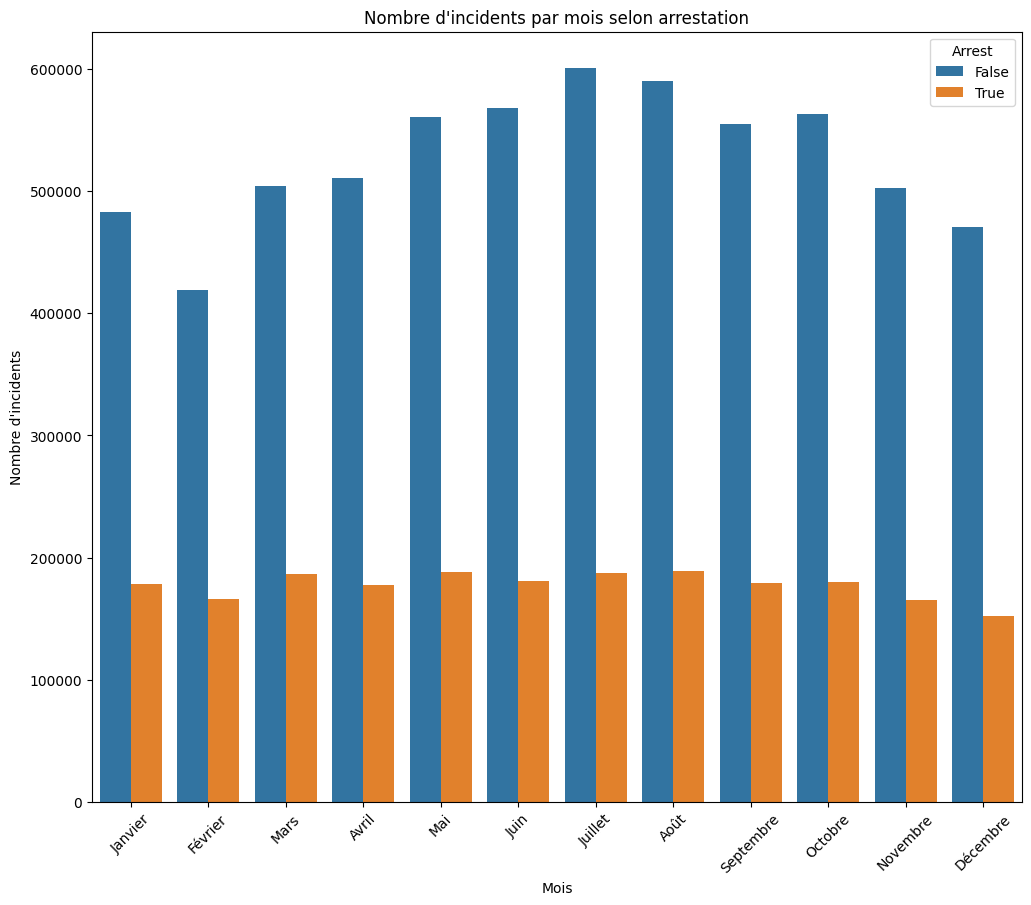

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

mois = (df.groupBy(["mois de l'incident","Arrest"])
          .count()
          .orderBy("mois de l'incident", ascending=True)
          ).toPandas()


ordre_mois = ["Janvier","Février","Mars","Avril","Mai","Juin",
              "Juillet","Août","Septembre","Octobre","Novembre","Décembre"]

mois["mois de l'incident"] = pd.Categorical(
    mois["mois de l'incident"],
    categories=ordre_mois,
    ordered=True
)

plt.figure(figsize=(12,10))
sns.barplot(x="mois de l'incident", y="count", hue="Arrest", data=mois)
plt.xlabel("Mois")
plt.ylabel("Nombre d'incidents")
plt.title("Nombre d'incidents par mois selon arrestation")
plt.xticks(rotation=45)
plt.show()

In [121]:
df.columns

['ID',
 'Case Number',
 'Date',
 'Block',
 'IUCR',
 'Primary Type',
 'Description',
 'Location Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'FBI Code',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Updated On',
 'Latitude',
 'Longitude',
 'Location',
 'Jour du mois',
 "mois de l'incident",
 'Jour de la semaine',
 'Week_end']

In [142]:
df.show()

+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+------------+------------------+------------------+--------+
|      ID|Case Number|               Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|         Updated On| Latitude| Longitude|            Location|Jour du mois|mois de l'incident|Jour de la semaine|Week_end|
+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+------------+----------------

In [122]:
df.columns

['ID',
 'Case Number',
 'Date',
 'Block',
 'IUCR',
 'Primary Type',
 'Description',
 'Location Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'FBI Code',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Updated On',
 'Latitude',
 'Longitude',
 'Location',
 'Jour du mois',
 "mois de l'incident",
 'Jour de la semaine',
 'Week_end']

In [123]:
df.groupBy("Primary Type").count().show(100,truncate=False)

+---------------------------------+-------+
|Primary Type                     |count  |
+---------------------------------+-------+
|OFFENSE INVOLVING CHILDREN       |60703  |
|CRIMINAL SEXUAL ASSAULT          |39039  |
|STALKING                         |6255   |
|PUBLIC PEACE VIOLATION           |54929  |
|OBSCENITY                        |960    |
|ARSON                            |14465  |
|GAMBLING                         |14666  |
|CRIMINAL TRESPASS                |227458 |
|ASSAULT                          |567464 |
|LIQUOR LAW VIOLATION             |15412  |
|MOTOR VEHICLE THEFT              |433448 |
|THEFT                            |1796249|
|BATTERY                          |1541161|
|ROBBERY                          |315341 |
|HOMICIDE                         |14041  |
|PUBLIC INDECENCY                 |218    |
|HUMAN TRAFFICKING                |138    |
|INTIMIDATION                     |5122   |
|PROSTITUTION                     |70454  |
|DECEPTIVE PRACTICE             

In [124]:
df.columns

['ID',
 'Case Number',
 'Date',
 'Block',
 'IUCR',
 'Primary Type',
 'Description',
 'Location Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'FBI Code',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Updated On',
 'Latitude',
 'Longitude',
 'Location',
 'Jour du mois',
 "mois de l'incident",
 'Jour de la semaine',
 'Week_end']

In [125]:
data=[("innocent",29),("Bigirimana",30)]
dff=spark.createDataFrame(data=data,schema=["Nom","age"])
dff = dff.withColumnRenamed("Nom","Name").withColumnRenamed("age","Years")
dff.show()

+----------+-----+
|      Name|Years|
+----------+-----+
|  innocent|   29|
|Bigirimana|   30|
+----------+-----+



# **Nombre de lignes**

In [126]:
df.count()

8458996

# Type de df

In [127]:
type(df)

pyspark.sql.classic.dataframe.DataFrame

# **Type des variables**

In [128]:
df.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: timestamp (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: integer (nullable = true)
 |-- Y Coordinate: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: timestamp (nullable = true)
 |-- Latitude: float (nullable = true)
 |-- Longitude: float (nullable = true)
 |-- Location: string (nullable = true)
 |-- Jour du mois: integer (nullable = true)
 |-- mois de l'incident: string (nullable = true

# **Manipulation des données**

In [129]:
from pyspark.sql.functions import col,to_timestamp
df=df.withColumn('Date',to_timestamp(col("Date"),"MM/dd/yyyy hh:mm:ss a")
)
from pyspark.sql.functions import col

# convertir les colonnes "Latitude" et "Location" en Float
df = df.withColumn("Latitude", col("Latitude").cast("float"))
df = df.withColumn("Longitude", col("Longitude").cast("float"))

df.show()

+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+------------+------------------+------------------+--------+
|      ID|Case Number|               Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|         Updated On| Latitude| Longitude|            Location|Jour du mois|mois de l'incident|Jour de la semaine|Week_end|
+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+------------+----------------

**Pour afficher les noms des colonnes **

In [130]:
df.columns

['ID',
 'Case Number',
 'Date',
 'Block',
 'IUCR',
 'Primary Type',
 'Description',
 'Location Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'FBI Code',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Updated On',
 'Latitude',
 'Longitude',
 'Location',
 'Jour du mois',
 "mois de l'incident",
 'Jour de la semaine',
 'Week_end']

**Pour faire la sélection d'une colonne**

In [131]:
df.select(col('Description')).show(5)

+--------------------+
|         Description|
+--------------------+
|         TO PROPERTY|
|          TO VEHICLE|
|              SIMPLE|
|AGGRAVATED FINANC...|
|VIOLATE ORDER OF ...|
+--------------------+
only showing top 5 rows


In [132]:
df.select('Description').show()

+--------------------+
|         Description|
+--------------------+
|         TO PROPERTY|
|          TO VEHICLE|
|              SIMPLE|
|AGGRAVATED FINANC...|
|VIOLATE ORDER OF ...|
|          TO VEHICLE|
|HARASSMENT BY TEL...|
|FINANCIAL IDENTIT...|
|    TELEPHONE THREAT|
|      NON-AGGRAVATED|
|HARASSMENT BY ELE...|
|STATE BENEFITS FRAUD|
|      $500 AND UNDER|
|          TO VEHICLE|
|ARMED - KNIFE / C...|
|     POSSESS - CRACK|
|UNLAWFUL POSSESSI...|
|       FROM BUILDING|
|      $500 AND UNDER|
|UNLAWFUL POSSESSI...|
+--------------------+
only showing top 20 rows


*pour sélectionner plusieurs colonnes*

In [133]:
df.select('Date','Block','IUCR','Primary Type').show()

+-------------------+--------------------+----+--------------------+
|               Date|               Block|IUCR|        Primary Type|
+-------------------+--------------------+----+--------------------+
|2025-12-05 00:00:00|   053XX N LYNCH AVE|1310|     CRIMINAL DAMAGE|
|2025-12-05 00:00:00|  112XX S VERNON AVE|1320|     CRIMINAL DAMAGE|
|2025-12-05 00:00:00| 090XX S HOUSTON AVE|0560|             ASSAULT|
|2025-12-05 00:00:00| 068XX S KEATING AVE|1155|  DECEPTIVE PRACTICE|
|2025-12-05 00:00:00|038XX W ARTHINGTO...|4387|       OTHER OFFENSE|
|2025-12-05 00:00:00|    015XX W HOMER ST|1320|     CRIMINAL DAMAGE|
|2025-12-05 00:00:00|110XX S WENTWORTH...|2825|       OTHER OFFENSE|
|2025-12-05 00:00:00|049XX N WINCHESTE...|1153|  DECEPTIVE PRACTICE|
|2025-12-05 00:00:00|039XX S LAKE PARK...|2820|       OTHER OFFENSE|
|2025-12-05 00:00:00| 052XX S CORNELL AVE|0281|CRIMINAL SEXUAL A...|
|2025-12-05 00:00:00|      006XX W OAK ST|2826|       OTHER OFFENSE|
|2025-12-05 00:00:00| 048XX N SHER

**Example pour créer une nouvelle colonne avec la fonction lit**

In [134]:
from pyspark.sql.functions import lit
df.withColumn("ones",lit(1)).show()


+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+------------+------------------+------------------+--------+----+
|      ID|Case Number|               Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|         Updated On| Latitude| Longitude|            Location|Jour du mois|mois de l'incident|Jour de la semaine|Week_end|ones|
+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+---------+----------+--------------------+------------+------

# ***Filtration***

In [135]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


*crimes signalés le 25-12-2013*

In [136]:
fil=df.filter(col("Date")==lit("2023-12-5"))

Le nombre de crimes signalés à cette date

In [137]:
fil.count()

14

In [138]:
fil.distinct().count()

14

In [139]:
df.groupBy('Primary Type').count().show()

+--------------------+-------+
|        Primary Type|  count|
+--------------------+-------+
|OFFENSE INVOLVING...|  60703|
|CRIMINAL SEXUAL A...|  39039|
|            STALKING|   6255|
|PUBLIC PEACE VIOL...|  54929|
|           OBSCENITY|    960|
|               ARSON|  14465|
|            GAMBLING|  14666|
|   CRIMINAL TRESPASS| 227458|
|             ASSAULT| 567464|
|LIQUOR LAW VIOLATION|  15412|
| MOTOR VEHICLE THEFT| 433448|
|               THEFT|1796249|
|             BATTERY|1541161|
|             ROBBERY| 315341|
|            HOMICIDE|  14041|
|    PUBLIC INDECENCY|    218|
|   HUMAN TRAFFICKING|    138|
|        INTIMIDATION|   5122|
|        PROSTITUTION|  70454|
|  DECEPTIVE PRACTICE| 390214|
+--------------------+-------+
only showing top 20 rows


# **Le taux d'arrestation**

25.189348712305808

In [141]:
df.groupBy("Location").count().orderBy("count",ascending=False).show()

+--------------------+-----+
|            Location|count|
+--------------------+-----+
|                NULL|94226|
|(41.976290414, -8...|14759|
|(41.754592961, -8...|11067|
|(41.883500187, -8...| 9211|
|(41.897895128, -8...| 4999|
|(41.788987036, -8...| 3897|
|(41.909664252, -8...| 3763|
|(41.896888586, -8...| 3465|
|(41.868541914, -8...| 3135|
|(41.868180939, -8...| 3078|
|(41.979006297, -8...| 3031|
|(41.885487535, -8...| 2965|
|(41.88233367, -87...| 2893|
|(42.019399237, -8...| 2876|
|(41.736259984, -8...| 2867|
|(41.721627204, -8...| 2813|
|(41.882394062, -8...| 2707|
|(41.929743818, -8...| 2694|
|(41.891990384, -8...| 2683|
|(41.891694878, -8...| 2674|
+--------------------+-----+
only showing top 20 rows
